In [1]:
%load_ext watermark


In [2]:
import gc
import os

from hstrat import _auxiliary_lib as hstrat_aux
import numpy as np
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

hstrat_aux.seed_random(1)


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-10-25T14:17:47.593314+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1036-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas : 2.2.3
seaborn: 0.13.2
hstrat : 1.20.19
numpy  : 2.1.2
teeplot: 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2025-10-20-mls-strong-fossils__mdcstats__wse-async-ga")
teeplot_subdir


'2025-10-20-mls-strong-fossils__mdcstats__wse-async-ga'

## Get Data


In [5]:
df = pd.read_parquet(
    "https://osf.io/download/acptf/",
    columns=[
        "id",
        "ancestor_id",
        "trait_num0",
        "focal_trait_count",
    ],
).fillna(
    {"trait_num0": 0, "focal_trait_count": 0}
).astype(
    {
        "id": np.uint32,
        "ancestor_id": np.uint32,
        "trait_num0": np.uint32,
        "focal_trait_count": np.uint32,
    }
)
gc.collect()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7974003 entries, 0 to 7974002
Data columns (total 4 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   id                 uint32
 1   ancestor_id        uint32
 2   trait_num0         uint32
 3   focal_trait_count  uint32
dtypes: uint32(4)
memory usage: 121.7 MB


In [6]:
df


,id,ancestor_id,trait_num0,focal_trait_count
0,0,0,0,0
1,1,1,0,0
2,2,2,0,0
3,3,3,0,0
4,4,4,0,0
...,...,...,...,...
7973998,7973998,7967136,1,1
7973999,7973999,7973293,0,0
7974000,7974000,7973985,0,0
7974001,7974001,7965392,0,0


In [7]:
with hstrat_aux.log_context_duration("alifestd_mark_leaves", display):
    df = hstrat_aux.alifestd_mark_leaves(df, mutate=True)

with hstrat_aux.log_context_duration("alifestd_mark_roots", display):
    df = hstrat_aux.alifestd_mark_roots(df, mutate=True)

with hstrat_aux.log_context_duration(
    "alifestd_mark_num_leaves_asexual", display
):
    df = hstrat_aux.alifestd_mark_num_leaves_asexual(df, mutate=True)

with hstrat_aux.log_context_duration(
    "alifestd_mark_node_depth_asexual", display
):
    df = hstrat_aux.alifestd_mark_node_depth_asexual(df, mutate=True)

gc.collect()


'enter log_context_duration for alifestd_mark_leaves'

'exit log_context_duration for alifestd_mark_leaves\n!!! {"alifestd_mark_leaves": 0.20131921768188477}'

'enter log_context_duration for alifestd_mark_roots'

'exit log_context_duration for alifestd_mark_roots\n!!! {"alifestd_mark_roots": 0.019774675369262695}'

'enter log_context_duration for alifestd_mark_num_leaves_asexual'

'exit log_context_duration for alifestd_mark_num_leaves_asexual\n!!! {"alifestd_mark_num_leaves_asexual": 1.5138592720031738}'

'enter log_context_duration for alifestd_mark_node_depth_asexual'

'exit log_context_duration for alifestd_mark_node_depth_asexual\n!!! {"alifestd_mark_node_depth_asexual": 0.3168613910675049}'

17197

In [8]:
print(f"""
    {df["num_leaves"].max()=}
    {df.loc[df["is_root"], "num_leaves"].sum()=}
    {df["is_root"].sum()=}
""")



    df["num_leaves"].max()=np.uint32(1186649)
    df.loc[df["is_root"], "num_leaves"].sum()=np.uint64(4000000)
    df["is_root"].sum()=np.int64(8)



## Prep Data


In [9]:
summary = []
for trait in "trait_num0", "focal_trait_count":
    print(f"Processing trait: {trait}")
    absent = df["is_leaf"].values & (df[trait].values == 0)
    present = df["is_leaf"].values & (df[trait].values != 0)

    with hstrat_aux.log_context_duration(
        "alifestd_screen_trait_defined_clades_fitch_asexual", display
    ):
        df[f"mdc_{trait}"] = (
            hstrat_aux.alifestd_screen_trait_defined_clades_fitch_asexual(
                df,
                mutate=True,
                mask_trait_absent=absent,
                mask_trait_present=present,
                progress_wrap=tqdm,
            )
        )
        summary.append(
            {
                "trait": trait,
                "mdc_count": df[f"mdc_{trait}"].sum(),
                "mdc_mean": df[f"mdc_{trait}"].mean(),
            }
        )

    with hstrat_aux.log_context_duration(
        "alifestd_calc_clade_trait_frequency_asexual", display
    ):
        df[f"freq_{trait}"] = (
            hstrat_aux.alifestd_calc_clade_trait_frequency_asexual(
                df,
                mutate=True,
                mask_trait_absent=absent,
                mask_trait_present=present,
            )
        )

    for i in range(0, 101, 25):
        df[f"mdc_f{i}pct_{trait}"] = df[f"mdc_{trait}"] & (
            df[f"freq_{trait}"] >= i / 100
        )
        summary.append(
            {
                "trait": f"{trait}_f{i}pct",
                "mdc_count": df[f"mdc_f{i}pct_{trait}"].sum(),
                "mdc_mean": df[f"mdc_f{i}pct_{trait}"].mean(),
            }
        )

    gc.collect()

pd.DataFrame(summary)


Processing trait: trait_num0


'enter log_context_duration for alifestd_screen_trait_defined_clades_fitch_asexual'

100%|██████████| 83/83 [00:04<00:00, 18.02it/s]


'exit log_context_duration for alifestd_screen_trait_defined_clades_fitch_asexual\n!!! {"alifestd_screen_trait_defined_clades_fitch_asexual": 35.13450384140015}'

'enter log_context_duration for alifestd_calc_clade_trait_frequency_asexual'

...

100%|██████████| 83/83 [00:04<00:00, 17.87it/s]


'exit log_context_duration for alifestd_screen_trait_defined_clades_fitch_asexual\n!!! {"alifestd_screen_trait_defined_clades_fitch_asexual": 36.0954008102417}'

'enter log_context_duration for alifestd_calc_clade_trait_frequency_asexual'

'exit log_context_duration for alifestd_calc_clade_trait_frequency_asexual\n!!! {"alifestd_calc_clade_trait_frequency_asexual": 0.4997975826263428}'

,trait,mdc_count,mdc_mean
0,trait_num0,33621,0.004216
1,trait_num0_f0pct,33621,0.004216
2,trait_num0_f25pct,26920,0.003376
3,trait_num0_f50pct,22646,0.002840
4,trait_num0_f75pct,21499,0.002696
5,trait_num0_f100pct,19600,0.002458
6,focal_trait_count,228008,0.028594
7,focal_trait_count_f0pct,228008,0.028594
8,focal_trait_count_f25pct,186017,0.023328
9,focal_trait_count_f50pct,137802,0.017281


## Example Plot


,num_leaves
count,132107.000000
mean,1.034601
std,0.214158
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,5.000000


,num_leaves
count,33621.000000
mean,63.440171
std,354.370779
min,1.000000
25%,3.000000
50%,9.000000
75%,31.000000
max,19596.000000


teeplots/2025-10-20-mls-strong-fossils__mdcstats__wse-async-ga/filter=f75pct_+hue=one+marker=o+viz=stripplot+x=treatment+y=num-leaves+ext=.pdf
teeplots/2025-10-20-mls-strong-fossils__mdcstats__wse-async-ga/filter=f75pct_+hue=one+marker=o+viz=stripplot+x=treatment+y=num-leaves+ext=.png


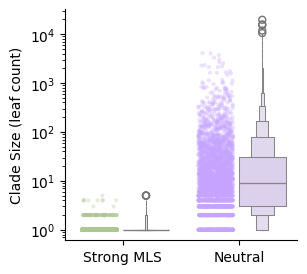

,num_leaves
count,228008.000000
mean,14.603720
std,256.358524
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,32694.000000


,num_leaves
count,33621.000000
mean,63.440171
std,354.370779
min,1.000000
25%,3.000000
50%,9.000000
75%,31.000000
max,19596.000000


teeplots/2025-10-20-mls-strong-fossils__mdcstats__wse-async-ga/filter=+hue=one+marker=o+viz=stripplot+x=treatment+y=num-leaves+ext=.pdf
teeplots/2025-10-20-mls-strong-fossils__mdcstats__wse-async-ga/filter=+hue=one+marker=o+viz=stripplot+x=treatment+y=num-leaves+ext=.png


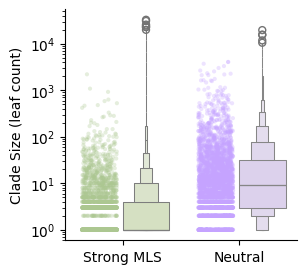

In [10]:

for f in ["f75pct_", ""]:
    data1 = df.loc[df[f"mdc_{f}focal_trait_count"], "num_leaves"].to_frame()
    data1["treatment"] = "Strong MLS"
    display(data1.describe())
    data1["one"] = 1

    data2 = df.loc[df["mdc_trait_num0"], "num_leaves"].to_frame()
    display(data2.describe())
    data2["treatment"] = "Neutral"
    data2["one"] = 1

    strip_args = dict(
        x='treatment',
        y='num_leaves',
        hue="one",
        order=['Strong MLS', 'Neutral'],
        hue_order=[1, 2],
        alpha=0.3,
        dodge=True,
        jitter=0.3,
        legend=False,
        marker="o",
        s=3,
    )
    boxen_args = dict(
        x='treatment',
        y='num_leaves',
        hue="one",
        hue_order=[2, 1],
        dodge=True,
        legend=False,
    )

    with tp.teed(
        sns.stripplot,
        data=data1.sample(n=3000, random_state=1),
        **strip_args,
        palette=["#ACC791"] * 2,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"filter": f},
    ) as ax:
        sns.stripplot(
            data=data2.sample(n=3000, random_state=1),
            **strip_args,
            palette=["#C5A3FF"] * 2,
        )

        sns.boxenplot(
            data=data1,
            **boxen_args,
            ax=ax,
            palette=["#D6E5BD"] * 2,
        )
        sns.boxenplot(
            data=data2,
            **boxen_args,
            ax=ax,
            palette=["#DBCDF0"] * 2,
        )

        ax.set_yscale("log")
        ax.set_xlabel("")
        ax.set_ylabel("Clade Size (leaf count)")
        sns.despine(ax=ax)
        ax.figure.set_size_inches(3, 3)

    gc.collect()
